In [5]:
#Import Kaggle dataset
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')


In [19]:
!kaggle datasets download -d ayuraj/asl-dataset
! unzip -q "/content/asl-dataset.zip"

Dataset URL: https://www.kaggle.com/datasets/ayuraj/asl-dataset
License(s): CC0-1.0
  0% 0.00/56.9M [00:00<?, ?B/s]
100% 56.9M/56.9M [00:00<00:00, 2.14GB/s]


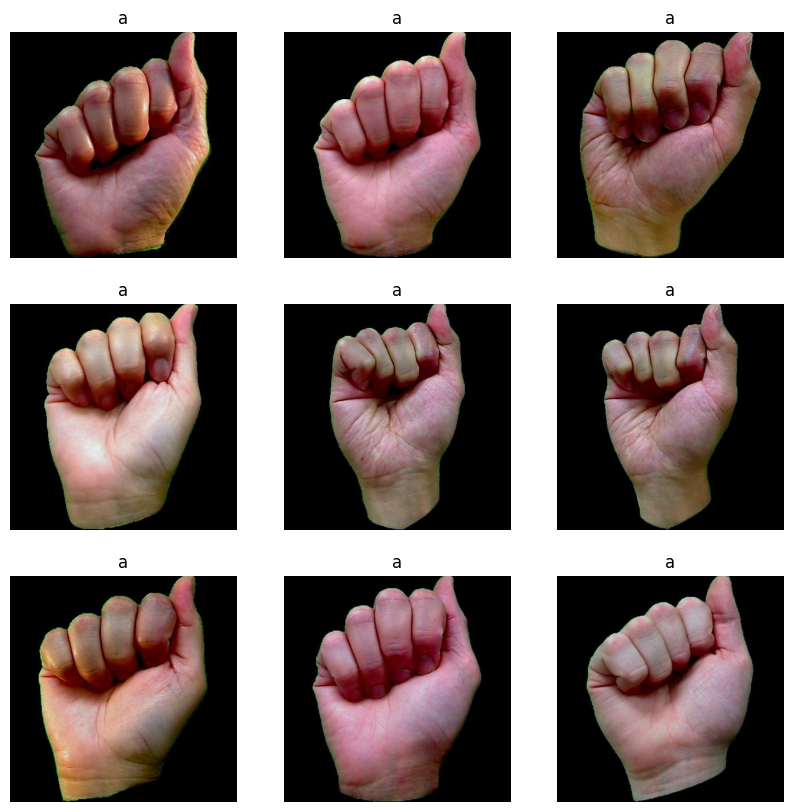

In [24]:
import matplotlib.pyplot as plt
import random

image_dir = "/content/asl_dataset/a"
image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpeg')]

plt.figure(figsize=(10, 10))
for i in range(min(9, len(image_files))):
    img_path = random.choice(image_files)
    img = plt.imread(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(os.path.dirname(img_path)))
    plt.axis('off')

plt.show()

## Add Random RGB Backgrounds to Dataset Images

This task involves iterating through the subdirectories of the `asl_dataset`, loading each image, generating a random RGB background, and adding the background to the image.

100%|██████████| 36/36 [00:13<00:00,  2.65it/s]


Processed 2515 images.


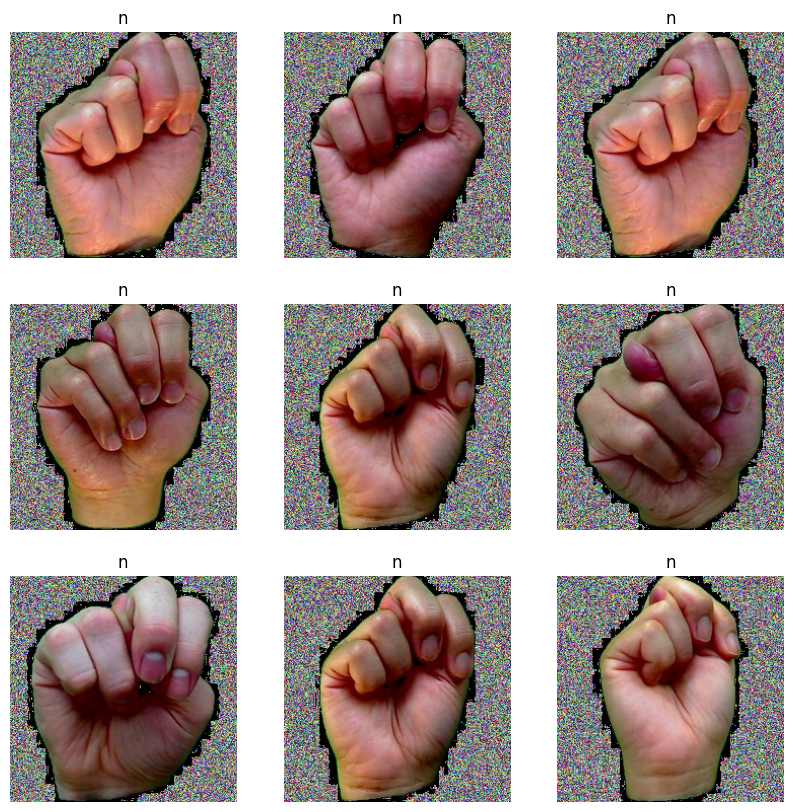

In [62]:
import os
import numpy as np
from PIL import Image
import tqdm
import cv2
data_dir = "/content/asl_dataset"
modified_images = []
image_labels = []
target_size = (224, 224)

# Iterate through the dataset directories, load each image, add a random background
for label in tqdm.tqdm(os.listdir(data_dir)):
    label_dir = os.path.join(data_dir, label)
    if os.path.isdir(label_dir):
        for f in os.listdir(label_dir):
            if f.endswith('.jpeg'):
                img_path = os.path.join(label_dir, f)
                try:
                    img = cv2.imread(img_path)

                    # Convert to RGB and resize before applying mask and background
                    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                    img_pil = img_pil.resize(target_size)
                    img_array = np.array(img_pil)

                    # Mask based on pure black pixels in the resized RGB image
                    mask = np.all(img_array == [0, 0, 0], axis=-1)
                    random_bg = np.random.randint(0, 256, img_array.shape, dtype=np.uint8)
                    modified_array = np.where(mask[..., None], random_bg, img_array)

                    modified_images.append(modified_array)
                    image_labels.append(label)
                except Exception as e:
                    print(f"Error processing image {img_path}: {e}")

print(f"Processed {len(modified_images)} images.")

plt.figure(figsize=(10, 10))
for i in range(min(9, len(modified_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(modified_images[i])
    plt.title(image_labels[i])
    plt.axis('off')

plt.show()